# Classical Machine Learning Models for Fake News Detection

> **Project Objective:** Develop a robust classification pipeline to distinguish between "Real" and "Fake" news using high-dimensional TF-IDF features and optimized classical algorithms.

---

### 📋 Notebook Roadmap

1. **Dimensionality Reduction & Preprocessing**
    * Reducing feature space sparsity using **TruncatedSVD** (Latent Semantic Analysis).
    * Implementing **MinMaxScaler** to ensure feature compatibility with Multinomial Naive Bayes.

2. **Baseline Model Training**
    * Initial training of **K-Nearest Neighbors (KNN)** and **Multinomial Naive Bayes**.
    * Performing **5-Fold Cross-Validation** to establish performance stability.

3. **Advanced Evaluation & Visual Analytics**
    * Granular error analysis using **Confusion Matrices**.
    * Performance benchmarking via **ROC Curves** and **Precision-Recall Curves**.
    * Sensitivity analysis of **SVD Dimensions** vs. Model Accuracy.

4. **Hyperparameter Optimization**
    * Systematic tuning of $k$ (neighbors) and $\alpha$ (smoothing) via **GridSearchCV**.
    * Updating model states with optimized estimators for peak performance.

5. **Final Comparison & Model Export**
    * Comparative analysis of tuned configurations using F1-Score and Accuracy.
    * Automated serialization of the **Winning Model** and its associated metadata.

---

## Part 1: Model Training

In [1]:
"""
Classical Machine Learning Models for Fake News Detection
Trains KNN and Naive Bayes on pre-computed TF-IDF features
"""

import numpy as np
import os
from pathlib import Path
from joblib import load, dump
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

BASE_DIR = Path(os.getcwd())
while BASE_DIR.name != "nlp-fake-news-detector-transformers" and BASE_DIR.parent != BASE_DIR:
    BASE_DIR = BASE_DIR.parent

FEATURES_DIR = BASE_DIR / "data" / "saved_features"
MODELS_DIR = BASE_DIR / "results" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)


class ClassicalModels:
    """Train and evaluate KNN and Naive Bayes classifiers"""
    
    def __init__(self, X_train, X_test, y_train, y_test):
        """Initialize with training and test data"""
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        
        self.knn_model = None
        self.nb_model = None
    
    def train_knn(self, n_neighbors: int = 5):
        """Train KNN classifier"""
        self.knn_model = KNeighborsClassifier(n_neighbors=n_neighbors)
        self.knn_model.fit(self.X_train, self.y_train)

        y_pred = self.knn_model.predict(self.X_test)
        self.evaluate(self.knn_model, "KNN")

        return y_pred
    
    def train_naive_bayes(self, alpha: float = 1.0):
        """Train Naive Bayes classifier"""
        self.nb_model = MultinomialNB(alpha=alpha)
        self.nb_model.fit(self.X_train, self.y_train)

        y_pred = self.nb_model.predict(self.X_test)
        self.evaluate(self.nb_model, "Naive Bayes")

        return y_pred
    
    def evaluate(self, model, model_name: str):
        """Evaluate model and print metrics"""
        y_pred = model.predict(self.X_test)
        
        accuracy = accuracy_score(self.y_test, y_pred)
        precision = precision_score(self.y_test, y_pred)
        recall = recall_score(self.y_test, y_pred)
        f1 = f1_score(self.y_test, y_pred)
        
        print(f"\n{model_name} Results:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print("\nConfusion Matrix:")
        print(confusion_matrix(self.y_test, y_pred))
        print("\nClassification Report:")
        print(classification_report(self.y_test, y_pred))
    
    def save_model(self, model, filename: str):
        """Save trained model"""
        dump(model, MODELS_DIR / filename)
        print(f"Model saved as {filename}")

## Load Pre-computed TF-IDF Features

In [2]:
print("Loading pre-computed TF-IDF features...")
X_train_tfidf = load(FEATURES_DIR / "X_train_tfidf.joblib")
X_test_tfidf = load(FEATURES_DIR / "X_test_tfidf.joblib")
y_train = load(FEATURES_DIR / "y_train.joblib")
y_test = load(FEATURES_DIR / "y_test.joblib")

print("Features loaded successfully!")
print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"X_test_tfidf shape: {X_test_tfidf.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Loading pre-computed TF-IDF features...
Features loaded successfully!
X_train_tfidf shape: (1185752, 10000)
X_test_tfidf shape: (296438, 10000)
y_train shape: (1185752,)
y_test shape: (296438,)


In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler

# We reduce the features (e.g., from 5000 down to 100)
n_components = 100
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_train_reduced = svd.fit_transform(X_train_tfidf)
X_test_reduced = svd.transform(X_test_tfidf)

# MultinomialNB can't work with negative numbers, so we make everything 0 to 1
scaler = MinMaxScaler()
X_train_final = scaler.fit_transform(X_train_reduced)
X_test_final = scaler.transform(X_test_reduced)

# Update variables for the next cells
X_train_tfidf = X_train_final
X_test_tfidf = X_test_final

print(f"SVD and Scaling complete.")
print(f"New Shape: {X_train_tfidf.shape}")
print(f"Variance explained: {svd.explained_variance_ratio_.sum():.2%}")

SVD and Scaling complete.
New Shape: (1185752, 100)
Variance explained: 16.72%


### Analyze Variance Explained by TruncatedSVD

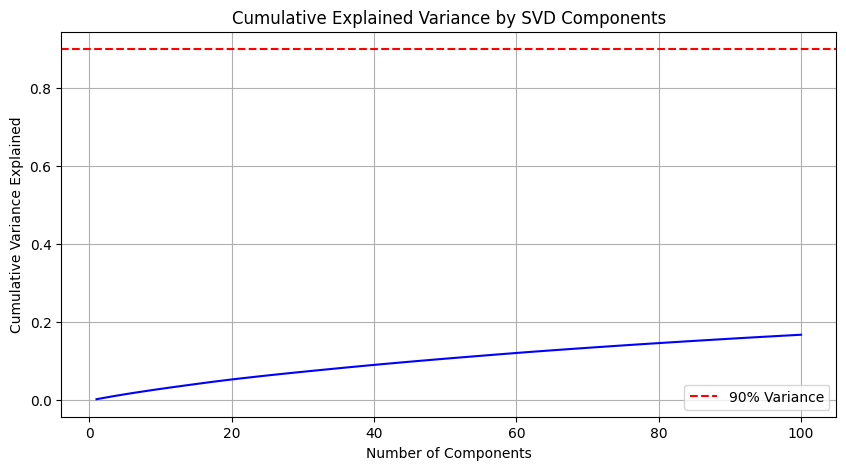

Total variance captured by 100 components: 16.72%


In [4]:
# Analyze cumulative variance explained and plot
import matplotlib.pyplot as plt
import numpy as np

# Calculate cumulative variance
cumulative_variance = np.cumsum(svd.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.title('Cumulative Explained Variance by SVD Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.legend()
plt.grid(True)
plt.show()

print(f"Total variance captured by {svd.n_components} components: {cumulative_variance[-1]:.2%}")

### Cross-Validation Analysis

In [ ]:
from sklearn.model_selection import cross_val_score

# Note: We use X_train_tfidf here because it was updated to the reduced/scaled version in Cell 3
print("Running Cross-Validation...")

# KNN CV
knn_cv = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_train_tfidf, y_train, cv=5)
print(f"KNN 5-Fold Accuracy: {knn_cv.mean():.4f} (+/- {knn_cv.std() * 2:.4f})")

# Naive Bayes CV
nb_cv = cross_val_score(MultinomialNB(), X_train_tfidf, y_train, cv=5)
print(f"Naive Bayes 5-Fold Accuracy: {nb_cv.mean():.4f} (+/- {nb_cv.std() * 2:.4f})")

Running Cross-Validation...
KNN 5-Fold Accuracy: 0.6828 (+/- 0.0034)
Naive Bayes 5-Fold Accuracy: 0.5058 (+/- 0.0000)


## Initialize and Train Models

In [6]:
# Initialize ClassicalModels with the processed TF-IDF features
print("Initializing ClassicalModels with processed data...")
models = ClassicalModels(X_train_tfidf, X_test_tfidf, y_train, y_test)

print("Models initialized successfully!")
print(f"X_train shape: {models.X_train.shape}")
print(f"X_test shape: {models.X_test.shape}")
print(f"y_train shape: {models.y_train.shape}")
print(f"y_test shape: {models.y_test.shape}")

Initializing ClassicalModels with processed data...
Models initialized successfully!
X_train shape: (1185752, 100)
X_test shape: (296438, 100)
y_train shape: (1185752,)
y_test shape: (296438,)


### Train KNN and naive bayes Classifiers

In [ ]:
# Train KNN classifier
print("Training KNN classifier...")
models.train_knn(n_neighbors=5)

# Train Naive Bayes classifier
print("Training Naive Bayes classifier...")
models.train_naive_bayes(alpha=1.0)

Training KNN classifier...

KNN Results:
Accuracy: 0.6837
Precision: 0.6755
Recall: 0.6930
F1-Score: 0.6842

Confusion Matrix:
[[101153  48780]
 [ 44970 101535]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.67      0.68    149933
           1       0.68      0.69      0.68    146505

    accuracy                           0.68    296438
   macro avg       0.68      0.68      0.68    296438
weighted avg       0.68      0.68      0.68    296438

Training Naive Bayes classifier...

Naive Bayes Results:
Accuracy: 0.5058
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Confusion Matrix:
[[149933      0]
 [146505      0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      1.00      0.67    149933
           1       0.00      0.00      0.00    146505

    accuracy                           0.51    296438
   macro avg       0.25      0.50      0.34    296438
weighted avg 

c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

array([0, 0, 0, ..., 0, 0, 0], shape=(296438,))

### Save Trained Models

In [8]:
# Save trained models
models.save_model(models.knn_model, "knn_model.joblib")
models.save_model(models.nb_model, "naive_bayes_model.joblib")

print("\nAll models trained and saved successfully!")

Model saved as knn_model.joblib
Model saved as naive_bayes_model.joblib

All models trained and saved successfully!


---

## Part 2: Advanced Evaluation & Analysis

Comprehensive evaluation including confusion matrices, ROC-AUC curves, PR curves, cross-validation scores, and learning curves.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score
from sklearn.model_selection import cross_val_score, cross_val_predict, learning_curve

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

### Confusion Matrix Visualization

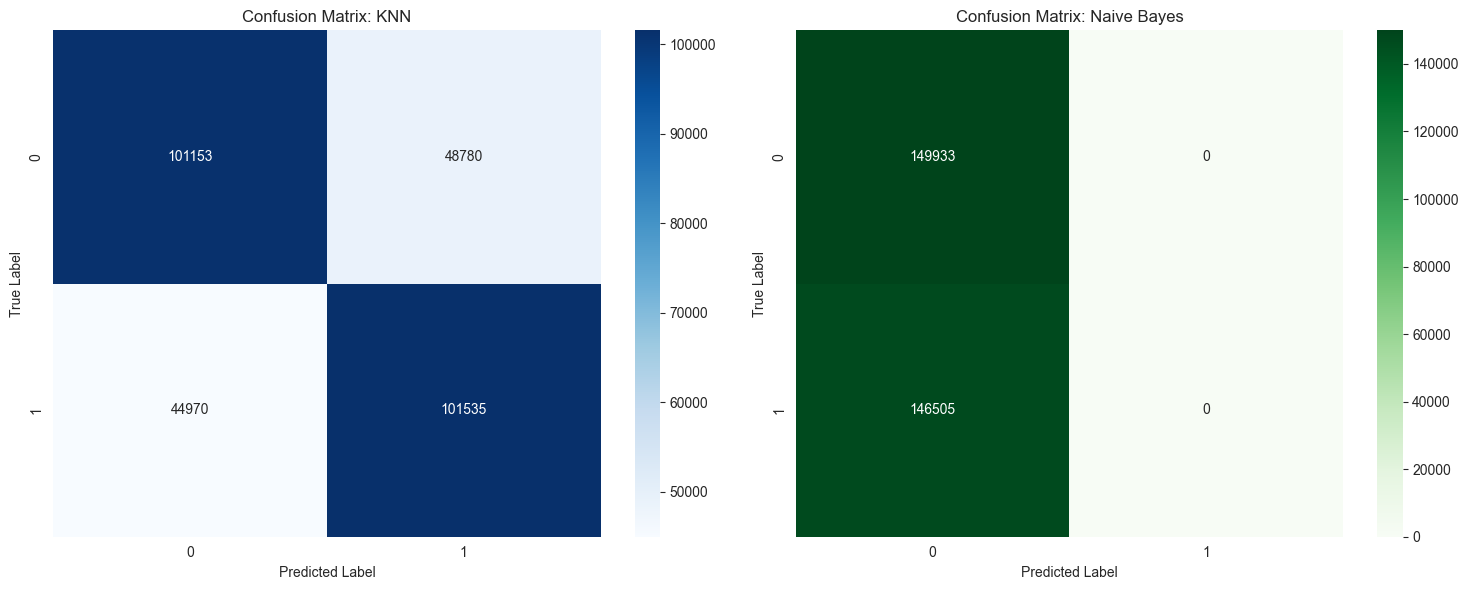

In [10]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(models_obj):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Data to plot
    plot_data = [
        (models_obj.knn_model, "KNN", "Blues"),
        (models_obj.nb_model, "Naive Bayes", "Greens")
    ]
    
    for ax, (model, name, color) in zip(axes, plot_data):
        if model is not None:
            # Generate predictions using the reduced test set
            y_pred = model.predict(models_obj.X_test)
            cm = confusion_matrix(models_obj.y_test, y_pred)
            
            sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax)
            ax.set_title(f'Confusion Matrix: {name}')
            ax.set_xlabel('Predicted Label')
            ax.set_ylabel('True Label')
        else:
            ax.set_text(0.5, 0.5, f'{name} Not Trained', ha='center')

    plt.tight_layout()
    plt.show()

# Run the visualization
plot_confusion_matrices(models)

### ROC-AUC and Precision-Recall Curves

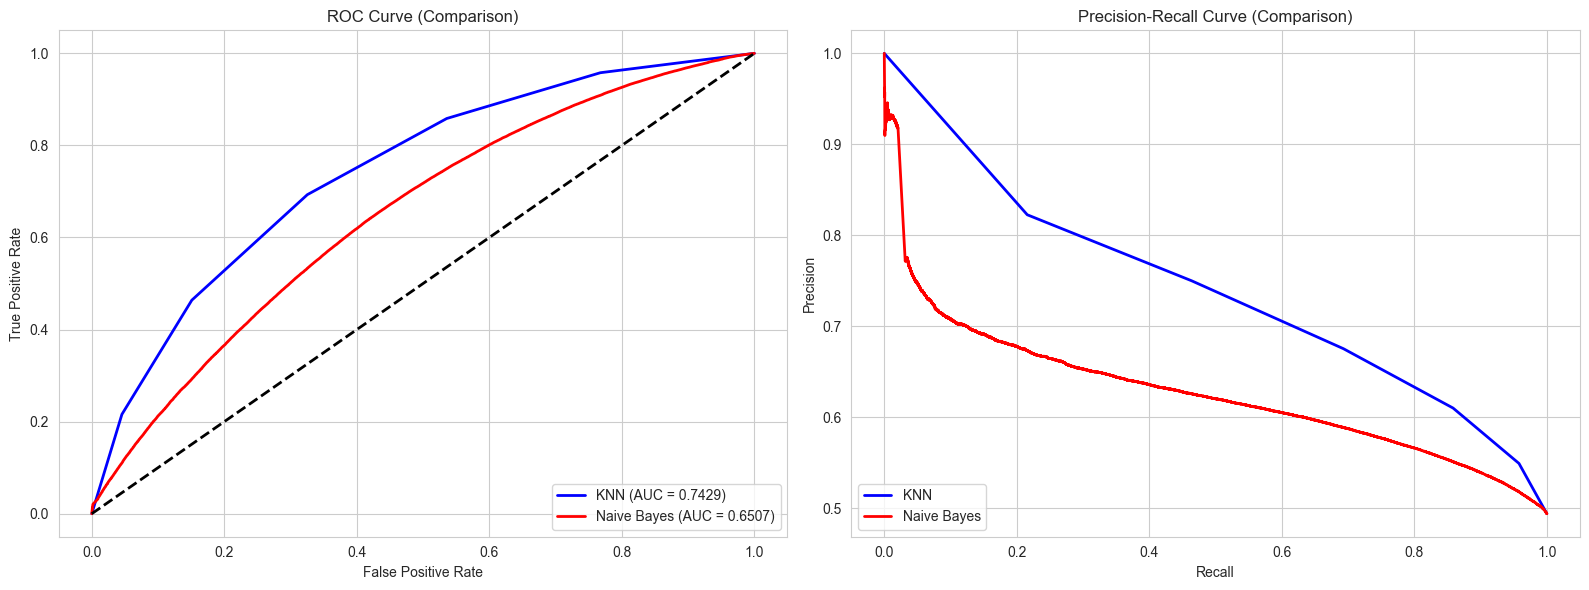

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

def plot_performance_curves(models_obj):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Models to evaluate
    model_configs = [
        (models_obj.knn_model, "KNN", "blue"),
        (models_obj.nb_model, "Naive Bayes", "red")
    ]
    
    for model, name, color in model_configs:
        if model is not None:
            # We use predict_proba to get the confidence scores for the "Positive" class
            y_probs = model.predict_proba(models_obj.X_test)[:, 1]
            
            # ROC Curve calculation
            fpr, tpr, _ = roc_curve(models_obj.y_test, y_probs)
            roc_auc = auc(fpr, tpr)
            ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')
            
            # Precision-Recall Curve calculation
            precision, recall, _ = precision_recall_curve(models_obj.y_test, y_probs)
            ax2.plot(recall, precision, color=color, lw=2, label=name)

    # ROC Plot Formatting
    ax1.plot([0, 1], [0, 1], 'k--', lw=2) # Random chance line
    ax1.set_title('ROC Curve (Comparison)')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.legend(loc="lower right")
    
    # PR Plot Formatting
    ax2.set_title('Precision-Recall Curve (Comparison)')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

# Run the visualization
plot_performance_curves(models)

### Train and Evaluate Models on Reduced Features

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Define the dimensions we will test
dimensions = [10, 50, 100, 200]
knn_results = []
nb_results = []

# We need the original raw TF-IDF features to restart the reduction each time
# Reloading from the original variables loaded in Cell 2
X_train_raw = load(FEATURES_DIR / "X_train_tfidf.joblib")

print("Testing different dimensions (this may take a moment)...")

for d in dimensions:
    # Reduce dimensions
    test_svd = TruncatedSVD(n_components=d, random_state=42)
    X_reduced = test_svd.fit_transform(X_train_raw)
    
    # Scale for Naive Bayes
    X_scaled = MinMaxScaler().fit_transform(X_reduced)
    
    # Evaluate KNN (using 3-fold CV for speed during testing)
    knn_score = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_scaled, y_train, cv=3).mean()
    knn_results.append(knn_score)
    
    # Evaluate Naive Bayes
    nb_score = cross_val_score(MultinomialNB(), X_scaled, y_train, cv=3).mean()
    nb_results.append(nb_score)
    
    print(f"Components: {d} | KNN Acc: {knn_score:.4f} | NB Acc: {nb_score:.4f}")

# Plot the comparison
plt.figure(figsize=(10, 6))
plt.plot(dimensions, knn_results, marker='o', label='KNN Accuracy', color='blue')
plt.plot(dimensions, nb_results, marker='s', label='Naive Bayes Accuracy', color='red')

plt.title('Model Accuracy vs. Number of SVD Components')
plt.xlabel('Number of Components (Dimensions)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Testing different dimensions (this may take a moment)...
Components: 10 | KNN Acc: 0.6548 | NB Acc: 0.5058
Components: 50 | KNN Acc: 0.6747 | NB Acc: 0.5058
Components: 100 | KNN Acc: 0.6812 | NB Acc: 0.5058
Components: 200 | KNN Acc: 0.6844 | NB Acc: 0.5058


MemoryError: Unable to allocate 4.51 GiB for an array with shape (1185752, 510) and data type float64

Exception ignored in: 'scipy.linalg._decomp_lu_cython.lu_decompose'
Traceback (most recent call last):
  File "c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\linalg\_decomp_lu.py", line 367, in lu
    lu_dispatcher(a1, u, p, permute_l)
numpy._core._exceptions._ArrayMemoryError: Unable to allocate 4.51 GiB for an array with shape (1185752, 510) and data type float64


KeyboardInterrupt: 

---

## Part 3: Hyperparameter Tuning

### Tune KNN and Naive Bayes Hyperparameters

In [ ]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Dictionary to store tuning results
tuning_results = {}

# Define Params
knn_params = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance']
}

nb_params = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

# Initialize and Fit
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, n_jobs=-1)
nb_grid = GridSearchCV(MultinomialNB(), nb_params, cv=5, n_jobs=-1)

knn_grid.fit(X_train_tfidf, y_train)
nb_grid.fit(X_train_tfidf, y_train)

# We store the best score and the best parameters to use them later
tuning_results['KNN'] = {
    'best_score': knn_grid.best_score_,
    'best_params': knn_grid.best_params_
}

tuning_results['Naive Bayes'] = {
    'best_score': nb_grid.best_score_,
    'best_params': nb_grid.best_params_
}

# Update the main models object with the best estimators found
models.knn_model = knn_grid.best_estimator_
models.nb_model = nb_grid.best_estimator_

print(f"Best KNN Params: {knn_grid.best_params_}")
print(f"Best NB Params: {nb_grid.best_params_}")

MemoryError: Unable to allocate 181. MiB for an array with shape (237150, 100) and data type float64

---

## Part 5: Final Comparison & Model Selection

Compare all model configurations and select the best performing model for deployment.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define a helper function to get all metrics
def get_metrics(model, X, y):
    y_pred = model.predict(X)
    return {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred)
    }

# Gather results using the TUNED models stored in our object
results_data = {
    'Tuned KNN': get_metrics(models.knn_model, X_test_tfidf, y_test),
    'Tuned Naive Bayes': get_metrics(models.nb_model, X_test_tfidf, y_test)
}

# Create DataFrame for a clean table view
comparison_df = pd.DataFrame(results_data).T

print("Final Model Comparison (Test Set):")
display(comparison_df) # Use display() for a prettier table in Jupyter

# Plot the comparison for the final report
comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Performance Comparison: Tuned KNN vs. Tuned Naive Bayes')
plt.ylabel('Score (0.0 - 1.0)')
plt.ylim(0, 1.1) # Gives some room at the top for the legend
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Save Best Model Configuration

In [ ]:
import json

# Determine the best model based on F1-Score
best_model_name = comparison_df['F1-Score'].idxmax()

if best_model_name == 'Tuned KNN':
    best_model = models.knn_model
    final_params = knn_grid.best_params_
else:
    best_model = models.nb_model
    final_params = nb_grid.best_params_

print(f"🏆 The best performing model is: {best_model_name}")

# Save the best model object
dump(best_model, MODELS_DIR / "best_model.joblib")

# Save metadata/configuration (The "Identity Card" for the model)
metadata = {
    "model_type": best_model_name,
    "svd_components": n_components,
    "best_hyperparameters": final_params,
    "final_test_metrics": comparison_df.loc[best_model_name].to_dict()
}

with open(MODELS_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print(f"\n✅ Success!")
print(f"Model saved as: {MODELS_DIR}/best_model.joblib")
print(f"Metadata saved as: {MODELS_DIR}/model_metadata.json")